<font face="Garamond">

<center> <font size="7" color="indigo"> Computational Data Mining – Homework 5
<center> <font size="5" color="indigo"> Feature selection using Singular Value Decomposition (SVD) versus classical methods

<center> <img src="https://upload.wikimedia.org/wikipedia/commons/f/fa/Amirkabir-University-of-Technology-Logo.png" width="200"/>


<center> <font size="4" color="darkblue"> Amirkabir University of Technology – Fall 2025


In [36]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib_venn import venn2

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline

sns.set_theme(
    style="whitegrid",
    rc={"figure.dpi": 120, "font.family": "serif", "font.size": 10}
)

<font face="Book Antiqua">

# Part 1: Industrial Data Preparation (SECOM Dataset)

<font face="Book Antiqua">

## Step 1.1: Data Loading

In [2]:
X = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data",
    sep=" ",
    header=None,
    na_values="NaN"
)

y = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data",
    sep=" ",
    header=None
).iloc[:, 0]

In [3]:
X.shape

(1567, 590)

In [4]:
X = X.loc[:, X.nunique(dropna=True) > 1]

In [5]:
X.shape

(1567, 474)

In [6]:
total_cols = X.shape[1]
cols_with_nan = X.isna().any().sum()

print(f"Total columns: {total_cols}, Columns with NaN: {cols_with_nan}")

Total columns: 474, Columns with NaN: 422


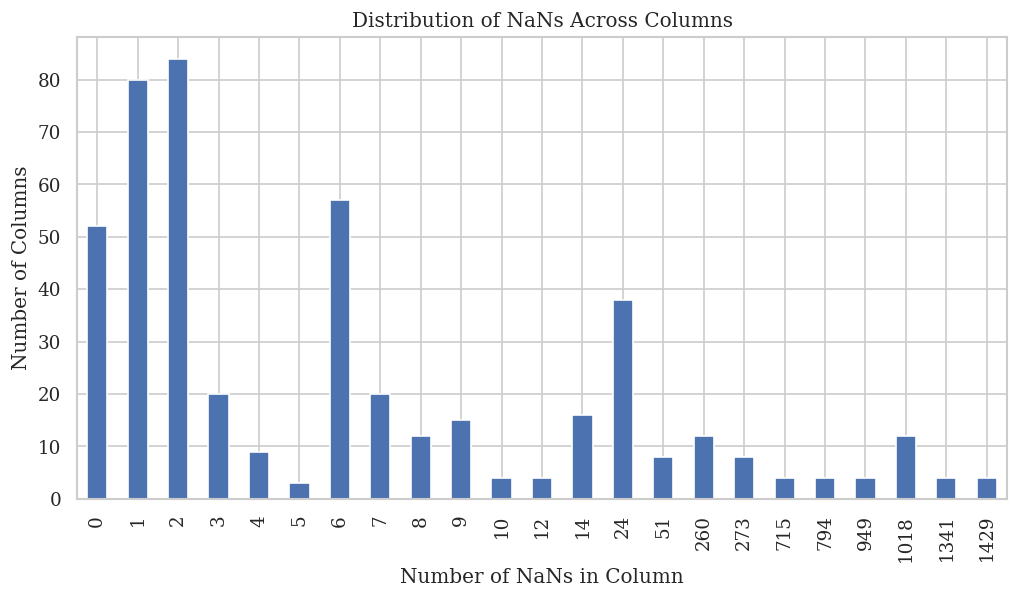

In [7]:
nan_counts = X.isna().sum()
nan_distribution = nan_counts.value_counts().sort_index()
plt.figure(figsize=(10,5))
nan_distribution.plot(kind='bar')
plt.xlabel('Number of NaNs in Column')
plt.ylabel('Number of Columns')
plt.title('Distribution of NaNs Across Columns')
plt.show()

In [9]:
X = X.loc[:, X.isna().sum() <= 52]

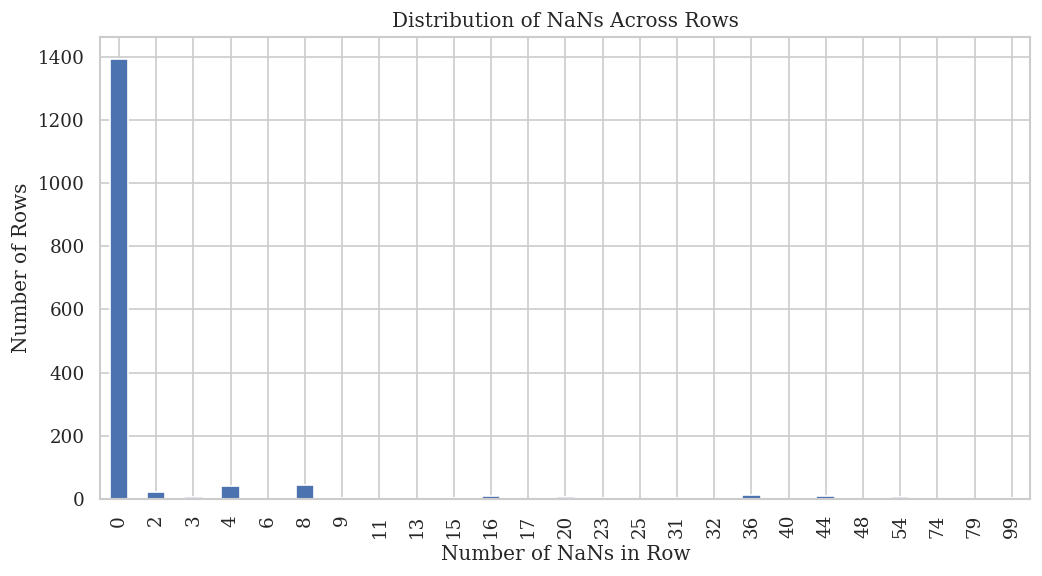

In [10]:
nan_counts = X.isna().sum(axis=1)
nan_distribution = nan_counts.value_counts().sort_index()

plt.figure(figsize=(10,5))
nan_distribution.plot(kind='bar')
plt.xlabel('Number of NaNs in Row')
plt.ylabel('Number of Rows')
plt.title('Distribution of NaNs Across Rows')
plt.show()

In [11]:
X = X.fillna(X.median())

In [12]:
y.value_counts()

,count
0,
-1,1463
1,104


<font face="Book Antiqua">

## Step 1.2: Data Normalization

In [13]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

In [14]:
df = X.copy()
df['label'] = y
df

,0,1,2,3,4,6,7,8,9,10,...,577,582,583,584,585,586,587,588,589,label
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,82.2467,0.1248,1.3424,-0.0045,-0.0057,...,11.7256,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,98.4689,0.1205,1.4333,-0.0061,-0.0093,...,17.8379,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,99.4122,0.1208,1.4616,-0.0013,0.0004,...,17.7267,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,98.7978,0.1213,1.4622,-0.0072,0.0032,...,19.2104,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1


In [15]:
df['label'].value_counts()

,count
label,
-1,1463
1,104


<font face="Book Antiqua">

# Part 2:  Classical Methods (Baseline for Comparison)

## Step 2.1 – Filter Method

In [16]:
X = df.drop(columns='label')
y = df['label']

mi = mutual_info_classif(X, y, random_state=42)

mi_scores = pd.Series(mi, index=X.columns)
top20_mi = mi_scores.sort_values(ascending=False).head(20)

print(top20_mi)

41     0.028769
331    0.027760
577    0.027203
477    0.026703
40     0.026407
122    0.026252
541    0.025142
411    0.024629
571    0.024460
416    0.023553
407    0.023486
573    0.022616
275    0.021804
570    0.021797
561    0.021793
130    0.020947
65     0.020774
443    0.020657
405    0.020425
33     0.019409
dtype: float64


## Step 2.2 – Wrapper Method (RFE)

In [17]:
X = df.drop(columns='label')
y = df['label']

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rfe = RFE(estimator=rf, n_features_to_select=20, step=8)

start = time.perf_counter()
rfe.fit(X, y)
end = time.perf_counter()

top20_rfe = X.columns[rfe.support_]

print("Top 20 features:", list(top20_rfe))
print("Execution time (seconds):", end - start)

Top 20 features: [2, 16, 25, 26, 38, 59, 64, 65, 71, 102, 103, 132, 153, 301, 348, 426, 473, 476, 477, 574]
Execution time (seconds): 106.84781009900001


<font face="Book Antiqua">

# Part 3: Algebraic Method (SVD-Based Feature Ranking)

## Step 3.1 – Decomposition

In [18]:
X = df.drop(columns='label').values

U, S, Vt = np.linalg.svd(X, full_matrices=False)

print(U.shape, S.shape, Vt.shape)

(1567, 422) (422,) (422, 422)


## Step 3.2 – Mathematical Analysis (Scoring)

In [19]:
Xmat = df.drop(columns='label').values
U, S, Vt = np.linalg.svd(Xmat, full_matrices=False)

k = min(10, S.size)

# compute scores: sum_{i=1..k} sigma_i^2 * |V_{i,j}|
weights = (S[:k]**2)[:, None]
scores_arr = (weights * np.abs(Vt[:k, :])).sum(axis=0)

feature_names = df.drop(columns='label').columns
scores = pd.Series(scores_arr, index=feature_names).sort_values(ascending=False)

print(scores.head(20))

90     2.322158e+11
162    2.030112e+11
21     1.494461e+11
161    1.431010e+11
23     1.054765e+11
297    9.940024e+10
0      7.914316e+10
55     7.502060e+10
22     7.146835e+10
296    6.623470e+10
1      6.556432e+10
2      5.782033e+10
88     4.749011e+10
3      3.697646e+10
225    2.741294e+10
24     2.698443e+10
133    2.636807e+10
159    2.583311e+10
115    1.964222e+10
46     1.927410e+10
dtype: float64


## Step 3.3 – Selection

In [20]:
top20_svd = scores.head(20)
top20_features = top20_svd.index.tolist()

print("Top 20 SVD features:", top20_features)

Top 20 SVD features: [90, 162, 21, 161, 23, 297, 0, 55, 22, 296, 1, 2, 88, 3, 225, 24, 133, 159, 115, 46]


<font face="Book Antiqua">

# Part 4: Geometric Analysis and Stability Evaluation

## Step 4.1 – Loading Plot

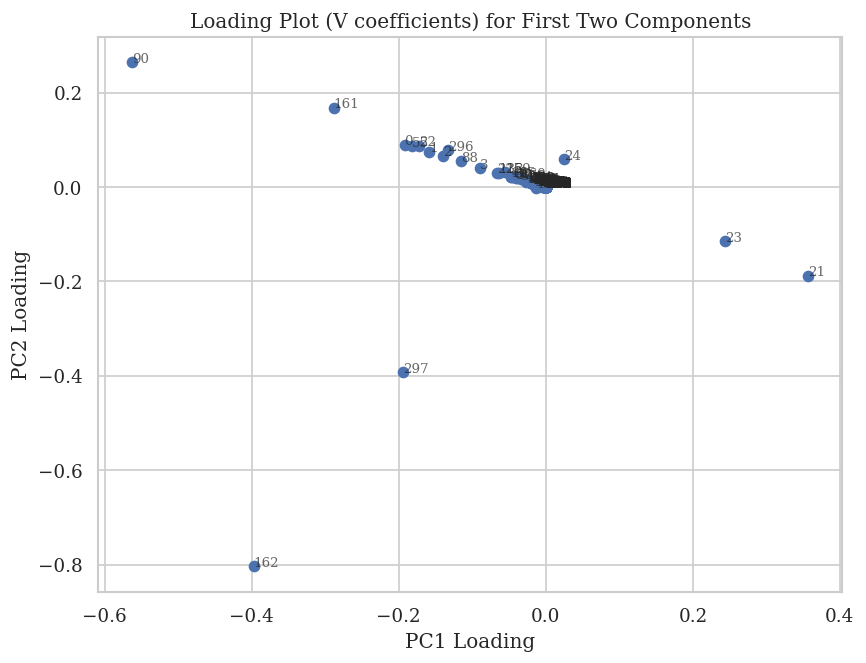

In [21]:
Vt_2 = Vt[:2, :]
feature_names = df.drop(columns='label').columns

plt.figure(figsize=(8,6))
plt.scatter(Vt_2[0, :], Vt_2[1, :])

for i, fname in enumerate(feature_names):
    plt.text(Vt_2[0, i], Vt_2[1, i], fname, fontsize=8, alpha=0.7)

plt.xlabel('PC1 Loading')
plt.ylabel('PC2 Loading')
plt.title('Loading Plot (V coefficients) for First Two Components')
plt.grid(True)
plt.show()

## Step 4.2 – Stability Test

In [22]:
X_orig = df.drop(columns='label').values
y = df['label'].values
feature_names = df.drop(columns='label').columns

noise_level = 0.05
X_noisy = X_orig + noise_level * np.random.randn(*X_orig.shape)

# --- RFE on noisy data ---
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rfe = RFE(estimator=rf, n_features_to_select=20, step=8)
rfe.fit(X_noisy, y)
top20_rfe_noisy = feature_names[rfe.support_].tolist()

# --- SVD-based on noisy data ---
U, S, Vt_noisy = np.linalg.svd(X_noisy, full_matrices=False)
k = 10
weights = (S[:k]**2)[:, None]
scores_noisy = (weights * np.abs(Vt_noisy[:k, :])).sum(axis=0)
scores_noisy_series = pd.Series(scores_noisy, index=feature_names)
top20_svd_noisy = scores_noisy_series.sort_values(ascending=False).head(20).index.tolist()

# --- Compare changes ---
rfe_change = len(set(top20_rfe) - set(top20_rfe_noisy))
svd_change = len(set(top20_features) - set(top20_svd_noisy))

print("Number of changed features (RFE):", rfe_change)
print("Number of changed features (SVD):", svd_change)

Number of changed features (RFE): 15
Number of changed features (SVD): 0


<font face="Book Antiqua">

# Part 5: Final Comparison and Evaluation

## Comparison Table

In [34]:
# -------------------------------
# Feature sets
# -------------------------------
feature_sets = {
    "MI": list(top20_mi.index),
    "RFE": list(top20_rfe),
    "SVD": list(top20_features)
}

# -------------------------------
# Measure MI selection time
# -------------------------------
X = df.drop(columns='label')
y = df['label']

start_mi = time.perf_counter()
_ = mutual_info_classif(X, y, random_state=42)
end_mi = time.perf_counter()

# -------------------------------
# Measure SVD selection time
# -------------------------------
start_svd = time.perf_counter()
U, S, Vt = np.linalg.svd(X.values, full_matrices=False)
k = 10
weights = (S[:k]**2)[:, None]
_ = (weights * np.abs(Vt[:k, :])).sum(axis=0)
end_svd = time.perf_counter()

# -------------------------------
# Feature selection times
# -------------------------------
feature_selection_time = {
    "MI": end_mi - start_mi,
    "RFE": end - start,      # already measured earlier
    "SVD": end_svd - start_svd
}

# -------------------------------
# Model evaluation
# -------------------------------
results = []

for name, features in feature_sets.items():
    X_sub = df[features]
    y = df['label']

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y, test_size=0.3, random_state=42, stratify=y
    )

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            max_iter=5000,
            class_weight='balanced'
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Method": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Feature Selection Time (s)": feature_selection_time[name]
    })

comparison_table = pd.DataFrame(results)
comparison_table

,Method,Accuracy,F1-score,Feature Selection Time (s)
0,MI,0.668790,0.161290,7.502350
1,RFE,0.770701,0.289474,106.847810
2,SVD,0.613588,0.133333,0.140207


## Overlap Analysis

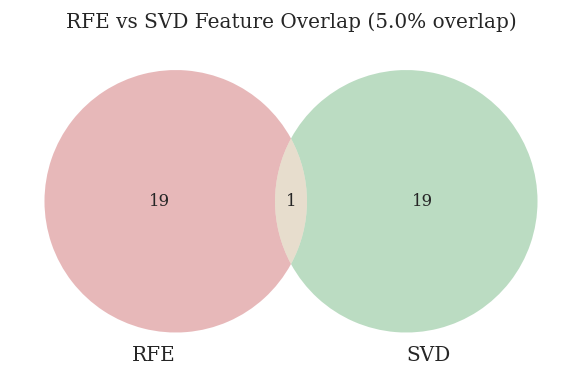

In [35]:
# Convert to sets
rfe_set = set(top20_rfe)
svd_set = set(top20_features)

# Compute overlap
overlap = rfe_set & svd_set
overlap_percent = (len(overlap) / 20) * 100

plt.figure(figsize=(6,6))
venn2([rfe_set, svd_set], set_labels=('RFE', 'SVD'))
plt.title(f'RFE vs SVD Feature Overlap ({overlap_percent:.1f}% overlap)')
plt.show()

## Conclusion

For an industrial application requiring high speed and interpretability, the Mutual Information (filter) method is recommended because it is computationally fast, stable, and produces easily explainable feature importance scores.